In [3]:
import pycbc
import numpy as np

In [4]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [5]:
from src.priors import PriorSampler
from src.waveform import generate_waveform
from src.noise import NoiseGenerator
from src.whitening import Whitening

In [6]:
sampler = PriorSampler()
noise_generator = NoiseGenerator()
whitener = Whitening()

theta = sampler.sample()

print(theta)

waveform = generate_waveform(theta)

noisy_waveform = noise_generator.add_noise(waveform)

whitened_waveform = whitener.whiten(noisy_waveform)

detector_noise = noisy_waveform - waveform


        Gravitational Wave Parameters (θ)
 Primary Mass (m1)      :    63.59 M☉
 Secondary Mass (m2)    :    39.84 M☉
 Primary Spin (χ1)      :  -0.7538
 Secondary Spin (χ2)    :   0.8464
 Luminosity Distance    :   364.84 Mpc
 Inclination (ι)        :   1.6626 rad


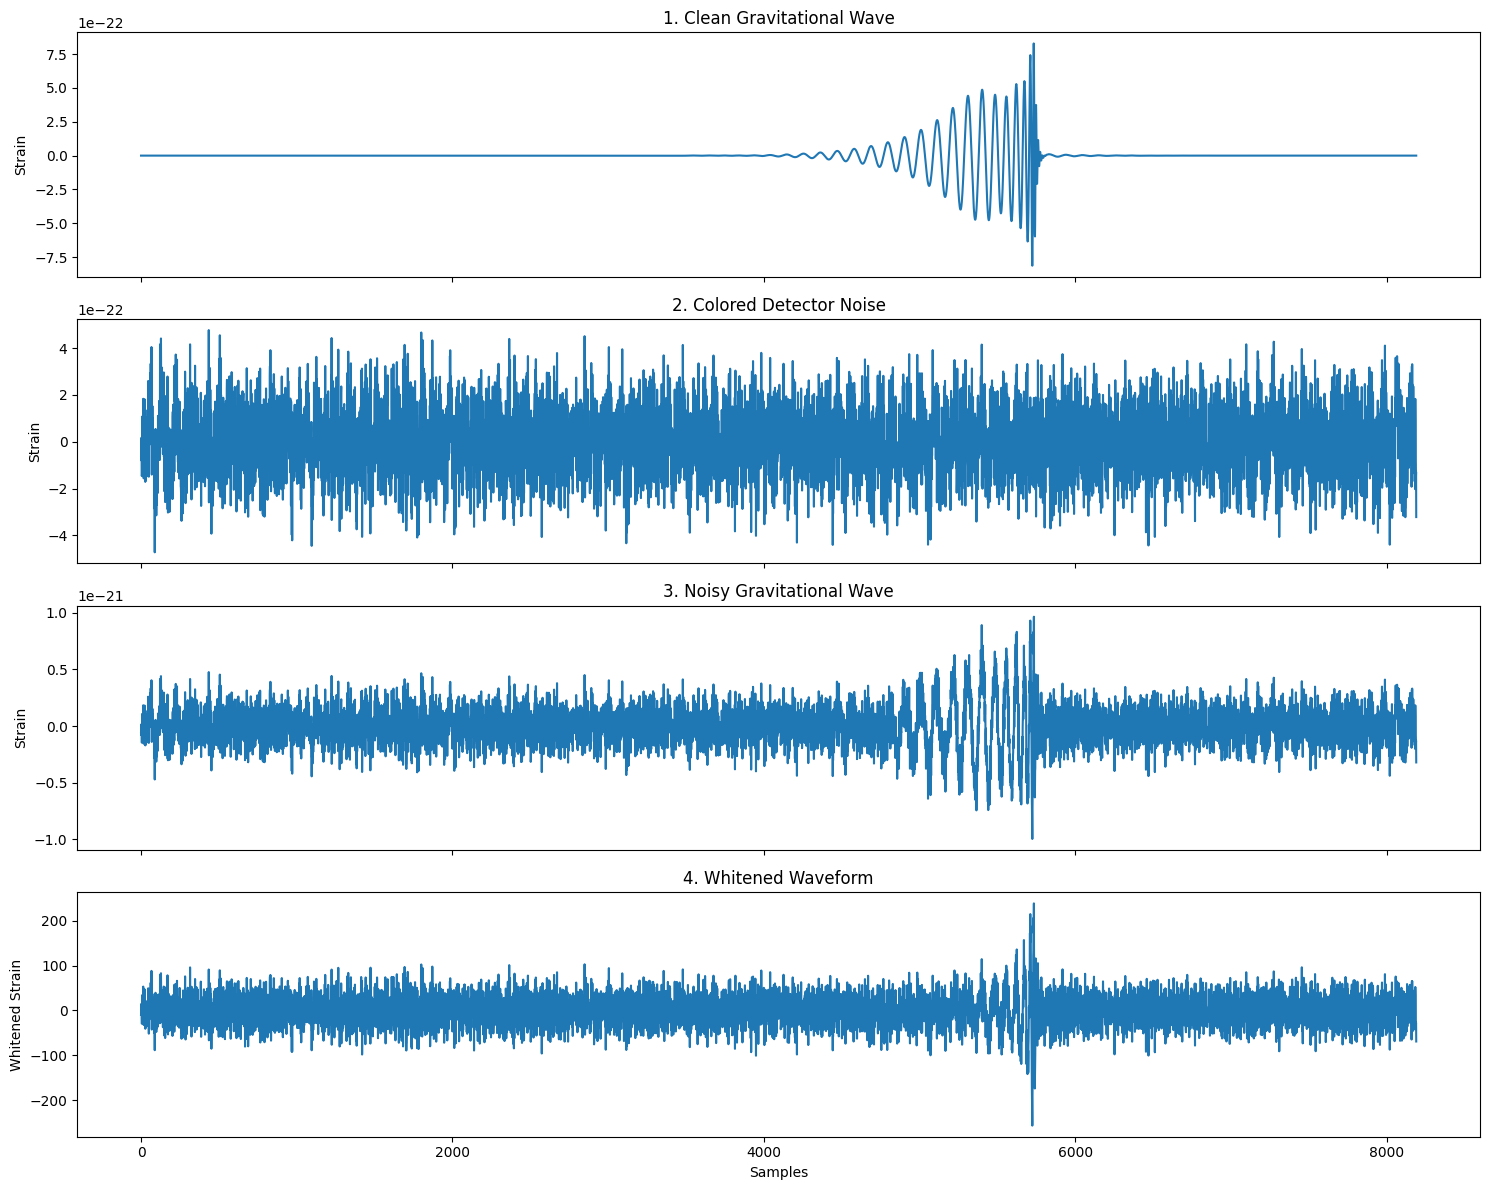

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

ax[0].plot(waveform)
ax[0].set_title("1. Clean Gravitational Wave")
ax[0].set_ylabel("Strain")

ax[1].plot(detector_noise)
ax[1].set_title("2. Colored Detector Noise")
ax[1].set_ylabel("Strain")

ax[2].plot(noisy_waveform)
ax[2].set_title("3. Noisy Gravitational Wave")
ax[2].set_ylabel("Strain")

ax[3].plot(whitened_waveform)
ax[3].set_title("4. Whitened Waveform")
ax[3].set_ylabel("Whitened Strain")
ax[3].set_xlabel("Samples")

plt.tight_layout()
plt.show()

In [8]:
import numpy as np

theta_array = np.array([
    theta.m1,
    theta.m2,
    theta.chi1,
    theta.chi2,
    theta.distance,
    theta.inclination
])

# Save using the project root path
np.save(PROJECT_ROOT / "data" / "sample_waveform.npy", whitened_waveform)
np.save(PROJECT_ROOT / "data" / "sample_theta.npy", theta_array)

print("✅ Sample saved successfully!")
print("Waveform:", PROJECT_ROOT / "data" / "sample_waveform.npy")
print("Parameters:", PROJECT_ROOT / "data" / "sample_theta.npy")

✅ Sample saved successfully!
Waveform: /home/vishnu/GW_BayesFlow_Project/data/sample_waveform.npy
Parameters: /home/vishnu/GW_BayesFlow_Project/data/sample_theta.npy


In [9]:
from src.dataset import DatasetGenerator

In [10]:
generator = DatasetGenerator(
    n_samples=1000,
    output_dir=PROJECT_ROOT / "data"
)

In [11]:
waveforms, parameters = generator.generate()


Generating 1000 samples...



Generating Dataset: 100%|███████████████████████████████████████| 1000/1000 [09:52<00:00,  1.69it/s]



Dataset generation complete!
Waveforms: (1000, 8192)
Parameters: (1000, 6)


In [8]:
from src.dataset import DatasetGenerator

generator = DatasetGenerator(
    n_samples=10000,
    output_dir=PROJECT_ROOT / "data"
)

In [9]:
waveforms, parameters = generator.generate()


Generating 10000 samples...



Generating Dataset: 100%|███████████████████████████████████| 10000/10000 [1:37:53<00:00,  1.70it/s]



Dataset generation complete!
Waveforms: (10000, 8192)
Parameters: (10000, 6)
